# ACCIDENT Baseline: Bounding Box Size Dynamics

## Competition Recap

This notebook provides a **baseline solution** for an ACCIDENT competition. The goal is to detect three key aspects of traffic accidents in video footage:

1. **When** did the accident happen? (temporal detection - time in seconds)
2. **Where** did it happen? (spatial detection - location coordinates within the frame)
3. **What type** of accident was it? (classification - e.g., t-bone, rear-end, single vehicle, etc.)

## Baseline Approach: Object Size Dynamics

### The Core Idea

When vehicles collide, their bounding boxes (the rectangular regions around detected objects) undergo dramatic changes:
- Boxes **overlap** as vehicles come into contact
- Boxes **merge or split** due to occlusion
- Box sizes **change abruptly** when impact occurs

### The Method

Our baseline solution addresses the temporal and spatial detection requirements through a multi-step pipeline:

1. **Detect objects** in each video frame using YOLO (You Only Look Once) object detection
2. **Calculate total bounding box area** per frame: $A_t = \sum_k \text{area}(\text{box}_{k,t})$
   - This aggregates all detected objects, making the method robust to temporary tracking issues
3. **Find the change point** using Kernel Change-Point Detection (KernelCPD)
   - This algorithm identifies when the box area pattern changes most dramatically
   - The most significant change point is predicted as the accident moment
4. **Locate the accident spatially** by finding the closest pair of objects in the predicted accident frame
   - Calculate bounding box centers for all detected objects
   - Find the two objects with minimum distance between their centers
   - Use the midpoint between these two objects as the accident location
   - Normalize coordinates to frame dimensions (0-1 range)
  
**Note**: This baseline only addresses temporal detection (when) and spatial detection (where). For accident type classification (what), we use default "single" (most common type).

### Imports & constants

In [ ]:
import cv2
import json
import pandas as pd
from tqdm import tqdm
import ruptures as rpt
import math
from itertools import combinations

from pathlib import Path
from typing import cast, Generator

import numpy as np
import torch
from ultralytics import YOLO

# Define paths and load video files
DETECTIONS_PATH = Path("./inference-yolo11x")
DETECTIONS_PATH.mkdir(parents=True, exist_ok=True)
DATASET_PATH = Path("../../dataset/real_videos")
video_paths = list((DATASET_PATH / "videos").iterdir())
metadata_df = pd.read_csv(DATASET_PATH/"metadata-real.csv", index_col="path")

%reload_ext autoreload
%autoreload 2

### Testing Configuration

**For Development/Testing**: By default, this notebook processes tiny subset of data(recommended for initial runs), you can tweak the `take = 2` line to set the subset size. The full (test) datasets runs for 8-12+ hours.

**For Full Submission**: Comment out or remove the `take = 2` line to process all videos in the dataset.

In [2]:
# Limit the number of videos processed for testing purposes
take = None
#take = 5 # comment out this line to run on all
video_paths = video_paths[:(take or len(video_paths))]

## Step 1: Object Detection with YOLO v11

In this step, we process each video frame to detect and track objects (primarily vehicles) using **YOLO v11 X-Large** model. This is a state-of-the-art object detection model that can identify and track multiple objects across video frames.

**Key configuration parameters**:
- **Resolution**: 1280x1280 pixels - higher resolution improves accuracy but increases processing time
- **Batch size**: 8 frames - processes multiple frames simultaneously for efficiency
- **Confidence threshold**: 0.15 - filters out low-confidence detections to reduce false positives

### Output

For each video, we generate a JSON file containing:
- **Frames**: Frame indices where detections occurred
- **Bounding boxes**: Coordinates of detected objects in each frame (x1, y1, x2, y2 format)
- **Path**: Relative path to the video file, acting as a video id

### Optional Data (Currently Unused)

The code also captures (but doesn't use in this baseline):
- `class_ids`: What type of object was detected (car, truck, etc.)
- `track_ids`: Unique IDs for tracking objects across frames
    - ByteTrack tracker is used to maintain object identities across frames
- `confidences`: Detection confidence scores

**💡 AI Improvement Suggestion**: These unused features could be valuable for:
- Filtering detections by confidence threshold
- Using object types to improve accident type classification
- Using track IDs to analyze vehicle trajectories before collision

In [3]:
# Algorithm parameters:
YOLO_MODEL_PATH="./yolo11x.pt" # Used pre-trained YOLO model.
YOLO_IMAGE_RESOLUTION=1280  # Input image resolution for YOLO (must be multiple of 32). Higher = more accurate but slower
YOLO_BATCH_SIZE=8  # Number of frames processed simultaneously. Increase for faster processing if GPU memory allows
CONFIDENCE_THRESHOLD = 0.15  # Minimum confidence score for object detection (0-1). Lower = more detections but more false positives
CUDA_DEVICE_ID = 0  # GPU device ID to use (0 for first GPU). Set to None or use CPU if no GPU available

class Tracker:
    def __init__(self, batch_size: int = YOLO_BATCH_SIZE):
        self.batch_size = batch_size

        self.model = YOLO(YOLO_MODEL_PATH)
        device = torch.device(f"cuda:{CUDA_DEVICE_ID}" if torch.cuda.is_available() else "cpu")
        self.model.to(device)
        print(f"Using YOLO model: {YOLO_MODEL_PATH} at {device.type} device.")
    
    def track(
            self, batches: Generator[list[cv2.typing.MatLike], None, None]
    ) -> dict:
        """Inference on images.
        
        Args:
            batches: Iterable of batched images.
        Returns:
            List of processed predictions.
        """
        bboxes = []
        frames_indices = []
        class_ids, track_ids, confidences = [], [], []
        try:
            for batch_index, batch in enumerate(batches):
                results = self.model.track(
                    batch,
                    imgsz=YOLO_IMAGE_RESOLUTION,  # must be a multiple of stride 32
                    verbose=False,
                    tracker="bytetrack.yaml",
                    persist=True,
                    conf=CONFIDENCE_THRESHOLD,
                )

                for i, x in enumerate(results):
                    if x.boxes is not None and x.boxes.is_track:
                        frames_indices.append(batch_index * self.batch_size + i)
                        bboxes.append(x.boxes.xyxy.cpu().numpy().tolist())
                        class_ids.append(x.boxes.cls.cpu().numpy().astype(int).tolist())
                        track_ids.append(x.boxes.id.cpu().numpy().tolist())
                        confidences.append(x.boxes.conf.cpu().numpy().tolist())
        except Exception as e:
            print(f"ERROR: {e}")
        finally:
            assert (
                hasattr(self.model, "predictor") 
                and self.model.predictor is not None
                and hasattr(self.model.predictor, "trackers") 
                and self.model.predictor.trackers is not None
            )
            
            for tracker in self.model.predictor.trackers:
                tracker.reset()

        return {
            "frames": frames_indices,
            "bboxes": bboxes,
            "class_ids": class_ids,
            "track_ids": track_ids,
            "confidences": confidences,
        }

    def load_batched(self, cap: cv2.VideoCapture):
        """Load video frames in batches.

        Args:
            cap: Opened cv2.VideoCapture object.
        Yields:
            Batches of video frames.
        """
        while True:
            batch: list[cv2.typing.MatLike] = []
            for _ in range(self.batch_size):
                ret, frame = cap.read()
                if not ret:
                    return
                batch.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            yield batch
    
    def process_video_file(self, video_path: Path) -> dict:
        """Track objects in a video file.

        Args:
            video_path: Path to a video file.
        Returns:
            Dict with list of detections and other relevant dat
        """
        cap = None
        try:
            cap = cv2.VideoCapture(video_path)

            detections = self.track(self.load_batched(cap))
            detections = {
                **detections,
                "path": str(video_path.relative_to(DATASET_PATH).as_posix())
            }
        finally:
            if cap:
                cap.release()

        return detections

In [4]:
tracker = Tracker()

for filename in tqdm(video_paths):
    filename = cast(Path, filename)
    predictions_path =  DETECTIONS_PATH / filename.with_suffix(".json").name

    # Skip if predictions already exist
    if predictions_path.exists():
        print(f"Skipping {predictions_path}. Predictions already exists.")
        continue

    # Process video
    predictions = tracker.process_video_file(filename)

    # Save predictions
    with open(predictions_path, "w") as f:
        json.dump(predictions, f)

Using YOLO model: ./yolo11x.pt at cpu device.


 21%|██        | 421/2027 [00:00<00:00, 4193.14it/s]

Skipping inference-yolo11x\-2UPLUV7JLg_00.json. Predictions already exists.
Skipping inference-yolo11x\-6SQSDj8cYU_00.json. Predictions already exists.
Skipping inference-yolo11x\-7-vQ4obVwQ_00.json. Predictions already exists.
Skipping inference-yolo11x\-9oifpjUxxM_00.json. Predictions already exists.
Skipping inference-yolo11x\-AztVDZ6cEE_00.json. Predictions already exists.
Skipping inference-yolo11x\-dmYsQc-odI_00.json. Predictions already exists.
Skipping inference-yolo11x\-dqVECYKOk4_00.json. Predictions already exists.
Skipping inference-yolo11x\-dVU8qW4ik8_00.json. Predictions already exists.
Skipping inference-yolo11x\-FQxK6HdxNU_00.json. Predictions already exists.
Skipping inference-yolo11x\-gbcp_G6NAE_00.json. Predictions already exists.
Skipping inference-yolo11x\-i9bRJWMtTo_00.json. Predictions already exists.
Skipping inference-yolo11x\-jZ5Rlhzzi4_00.json. Predictions already exists.
Skipping inference-yolo11x\-NgnSm_oEB4_00.json. Predictions already exists.
Skipping inf

 41%|████▏     | 841/2027 [00:00<00:00, 2672.92it/s]


Skipping inference-yolo11x\FAEmPbAt0Wk_00.json. Predictions already exists.
Skipping inference-yolo11x\FaI91W7BO04_00.json. Predictions already exists.
Skipping inference-yolo11x\Fb1XWmXZTZw_00.json. Predictions already exists.
Skipping inference-yolo11x\fbkRjY737QE_00.json. Predictions already exists.
Skipping inference-yolo11x\FbMyX_ZWAm8_00.json. Predictions already exists.
Skipping inference-yolo11x\fcc1sGDTQLM_00.json. Predictions already exists.
Skipping inference-yolo11x\fcJD3Xt4zzA_00.json. Predictions already exists.
Skipping inference-yolo11x\FD2WTKo0V94_00.json. Predictions already exists.
Skipping inference-yolo11x\fd3l6Z3OSXE_00.json. Predictions already exists.
Skipping inference-yolo11x\FDjxbPaxmho_00.json. Predictions already exists.
Skipping inference-yolo11x\fEijKQwtcD4_00.json. Predictions already exists.
Skipping inference-yolo11x\fEprGEfHTZE_00.json. Predictions already exists.
Skipping inference-yolo11x\FFkOuMBHngY_00.json. Predictions already exists.
Skipping in

100%|██████████| 2027/2027 [00:00<00:00, 3550.10it/s]

Skipping inference-yolo11x\nhEW6whH4HE_00.json. Predictions already exists.
Skipping inference-yolo11x\nHKTuIJZA1U_00.json. Predictions already exists.
Skipping inference-yolo11x\nHmyMVHNPDs_00.json. Predictions already exists.
Skipping inference-yolo11x\NHOOHKL_z8s_00.json. Predictions already exists.
Skipping inference-yolo11x\NhVQ26Tutwg_00.json. Predictions already exists.
Skipping inference-yolo11x\niL3O_tNdFY_00.json. Predictions already exists.
Skipping inference-yolo11x\NIwmS3dbHY0_00.json. Predictions already exists.
Skipping inference-yolo11x\njI11mpdwo0_00.json. Predictions already exists.
Skipping inference-yolo11x\njJxs1KozgE_00.json. Predictions already exists.
Skipping inference-yolo11x\NjK1CBPb0tY_00.json. Predictions already exists.
Skipping inference-yolo11x\NJvjYUBWAc0_00.json. Predictions already exists.
Skipping inference-yolo11x\NKA8MgHBw5A_00.json. Predictions already exists.
Skipping inference-yolo11x\nKC_z-VEBfE_00.json. Predictions already exists.
Skipping inf

## Step 2: Temporal Detection - When Did the Accident Happen?

### The Problem

We need to identify the exact moment (frame number and time) when the accident occurred in each video.

### Our Approach: Bounding Box Size Change Detection

The function `find_bbox_size_change()` implements our temporal detection heuristic:

1. **Calculate total bounding box area per frame**: Sum up the area of all detected bounding boxes in each frame
2. **Normalize the areas**: Convert to proportions (0-1) to make the method scale-invariant
3. **Apply Kernel Change-Point Detection**: Use the `ruptures` library's KernelCPD algorithm to find when the box area pattern changes most dramatically
4. **Return the change point**: The frame where the biggest change occurred is our predicted accident moment

### How It Works

**KernelCPD (Kernel Change-Point Detection)**: This algorithm looks for points where the statistical distribution of the data changes. In our case, it finds when the bounding box area pattern shifts (indicating collision).
We use a Radial Basis Function (RBF) kernel, which is good at detecting smooth changes in patterns.

### Edge Cases Handled

- **No detections in video**: If no objects are detected, returns the middle frame
- **Empty frames**: If a frame has no detections, uses the previous frame's area value or 0 on first frame

### Output

For each video, we get:
- `frame`: The predicted frame number where the accident occurred
- `accident_time`: The time in seconds (calculated as `frame / fps`)

**💡 AI Improvement Suggestions**:
- Use multiple change-point detection algorithms and ensemble their results
- Incorporate velocity/acceleration of bounding boxes
- Use temporal models (LSTM, Transformer) to learn accident patterns
- Consider the rate of change, not just the magnitude

In [5]:
def find_bbox_size_change(detections: dict) -> tuple[int, np.ndarray]:
    """
    Find biggest change in bbox sizes in video.

    Returns:
        int: A frame with biggest change in bbox sizes
    """
    bbox_sizes = []
    for bboxes in detections["bboxes"]:
        if len(bboxes) == 0:
            if len(bbox_sizes) > 0: 
                # If no bboxes detected in current frame, use the last known bbox size (assuming objects are still present but not detected)
                bbox_sizes.append(bbox_sizes[-1])
            else:
                # No bboxes detected (yet), default to 0
                bbox_sizes.append(0)
        else:
            bbox_pixel_size = sum([abs(x2 - x1) * abs(y2 - y1) for x1, y1, x2, y2 in bboxes])
            bbox_sizes.append(bbox_pixel_size)
    
    if np.sum(bbox_sizes) == 0:
        # No bboxes detected in video, return the middle frame
        return len(detections["frames"])//2, bbox_sizes
    bbox_sizes = np.array(bbox_sizes)
    bbox_sizes = bbox_sizes / np.sum(bbox_sizes)

    changes = rpt.KernelCPD(kernel="rbf").fit_predict(bbox_sizes, n_bkps=3)
    assert changes and len(changes) >= 1
    return ((detections["frames"][changes[0]] + detections["frames"][changes[0]+1]) / 2), bbox_sizes

In [6]:
results: dict[Path, dict] = {}
for video in tqdm(video_paths):
    video = cast(Path, video)
    with open(DETECTIONS_PATH / video.with_suffix(".json").name, "r") as f:
        info = json.load(f)

    # Get video metadata to calculate FPS and convert frame number to time
    metadata = metadata_df.loc[info["path"]]
    fps = metadata["no_frames"] / metadata["duration"]
    
    # Find frame with biggest change in bbox sizes
    frame, _ = find_bbox_size_change(info)
    results[info["path"]] = {"frame": frame, "accident_time": frame / fps}
    

100%|██████████| 2027/2027 [01:21<00:00, 24.80it/s]


## Step 3: Spatial Detection - Where Did the Accident Happen?

### The Problem

Given the predicted accident frame from Step 2, we need to identify the **location** (x, y coordinates) within the frame where the accident occurred.

### Our Approach: Closest Object Pair

The spatial detection heuristic works as follows:

1. **Extract bounding boxes from the accident frame**: Get all detected objects at the predicted accident moment
2. **Calculate bounding box centers**: For each detected object, find the center point of its bounding box
3. **Find the closest pair**: Among all detected objects, find the two objects whose centers are closest together
4. **Use the midpoint**: The accident location is predicted as the midpoint between these two closest centers
5. **Normalize coordinates**: Convert pixel coordinates to normalized coordinates (0-1) relative to frame dimensions

### Edge Cases

- **Only one object detected**: Use that object's center as the accident location
- **No objects detected**: Default to the center of the frame (0.5, 0.5)

### Output Format

Coordinates are normalized (0-1 range):
- `center_x`: X coordinate (0 = left edge, 1 = right edge)
- `center_y`: Y coordinate (0 = top edge, 1 = bottom edge)

**💡 AI Improvement Suggestions**:
- Consider object sizes when finding collision points (larger objects might indicate the collision)
- Use trajectory analysis to predict where objects will intersect
- Analyze overlap regions between bounding boxes
- Use attention mechanisms to focus on collision regions

In [7]:
def euclidean_distance(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def midpoint(p1, p2):
    return ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)

def predict_accident_location(
    video_paths: list[Path], results: dict[Path, dict]
) -> dict[Path, dict]:
    for video in tqdm(video_paths):
        with open(DETECTIONS_PATH / video.with_suffix(".json").name, "r") as f:
            info = json.load(f)

        result = results[info["path"]]
        accident_frame = int(result["frame"])
        metadata = metadata_df.loc[info["path"]]

        bboxes = next(bboxes for frame, bboxes in zip(info["frames"], info["bboxes"]) if frame == accident_frame)
        if len(bboxes) == 0: # no detections in the accident frame, use frame center
            result["center_x"] = 0.5
            result["center_y"] = 0.5
            continue

        bbox_centers = [midpoint((x1, y1), (x2, y2)) for (x1, y1, x2, y2) in bboxes]
        if len(bbox_centers) == 1: # only one detection, use its center
            result["center_x"] = bbox_centers[0][0] / metadata["width"]
            result["center_y"] = bbox_centers[0][1] / metadata["height"]
            continue

        (c1, c2) = min(
            combinations(bbox_centers, 2),
            key=lambda pair: euclidean_distance(pair[0], pair[1])
        )

        # prediction = midpoint of those two centers
        prediction_center = midpoint(c1, c2)
        result["center_x"] = prediction_center[0] / metadata["width"]
        result["center_y"] = prediction_center[1] / metadata["height"]
    return results

predict_accident_location(video_paths, results)

100%|██████████| 2027/2027 [00:47<00:00, 42.59it/s]


{'videos/-2UPLUV7JLg_00.mp4': {'frame': 20.5,
  'accident_time': np.float64(2.058048657718121),
  'center_x': np.float64(0.7869222005208333),
  'center_y': np.float64(0.37773002518547905)},
 'videos/-6SQSDj8cYU_00.mp4': {'frame': 65.5,
  'accident_time': np.float64(4.370265033407572),
  'center_x': np.float64(0.026915924346681233),
  'center_y': np.float64(0.0998803734779358)},
 'videos/-7-vQ4obVwQ_00.mp4': {'frame': 51.5,
  'accident_time': np.float64(3.847473815461347),
  'center_x': np.float64(0.6394719788522432),
  'center_y': np.float64(0.4814414766099718)},
 'videos/-9oifpjUxxM_00.mp4': {'frame': 24.5,
  'accident_time': np.float64(1.637176470588235),
  'center_x': np.float64(0.7335140840506847),
  'center_y': np.float64(0.1946244239807129)},
 'videos/-AztVDZ6cEE_00.mp4': {'frame': 38.5,
  'accident_time': np.float64(2.564236111111111),
  'center_x': np.float64(0.5188653111457825),
  'center_y': np.float64(0.15756263732910156)},
 'videos/-dmYsQc-odI_00.mp4': {'frame': 65.5,
  'ac

## Step 4. Export `submission.csv`

Finally, its submission time. For each test video, write one row to `submission.csv` containing the predicted `accident_time` in seconds

The remaining required fields are filled with fixed default values:

- `center_x` / `center_y`: `0.5` / `0.5` (image center)
- `type: "single"`

This ensures the submission format is valid while development focuses on predicting accident timing.

**💡 This is a major area for improvement!**

In [8]:
# Put the default type:
for result in results.values():
    result["type"] = "single"
    
results_df = pd.DataFrame([{"path": str(path), **i, "frame": None } for path, i in results.items()]).drop(columns=["frame"])
results_df.to_csv("output_bbox_dynamics.csv", index=False)
results_df

,path,accident_time,center_x,center_y,type
0,videos/-2UPLUV7JLg_00.mp4,2.058049,0.786922,0.377730,single
1,videos/-6SQSDj8cYU_00.mp4,4.370265,0.026916,0.099880,single
2,videos/-7-vQ4obVwQ_00.mp4,3.847474,0.639472,0.481441,single
3,videos/-9oifpjUxxM_00.mp4,1.637176,0.733514,0.194624,single
4,videos/-AztVDZ6cEE_00.mp4,2.564236,0.518865,0.157563,single
...,...,...,...,...,...
2022,videos/_lcVYPMK8RY_00.mp4,1.214492,0.953691,0.220318,single
2023,videos/_NywzqOXZGE_00.mp4,2.061354,0.649569,0.455892,single
2024,videos/_SK-OKBNWj0_00.mp4,5.783243,0.652851,0.760309,single
2025,videos/_wf9h2X_uU0_00.mp4,0.247492,0.192191,0.701422,single


## Bonus step: Visualization 📈

As a final step, we include a simple qualitative visualization to help interpret the baseline predictions.

What the visualization shows

- **Left panel**: the video frame at the predicted accident time, with the predicted accident location highlighted.

- **Right panel**: the evolution of the normalized overal bounding box size over time, with a vertical line marking the predicted accident moment.

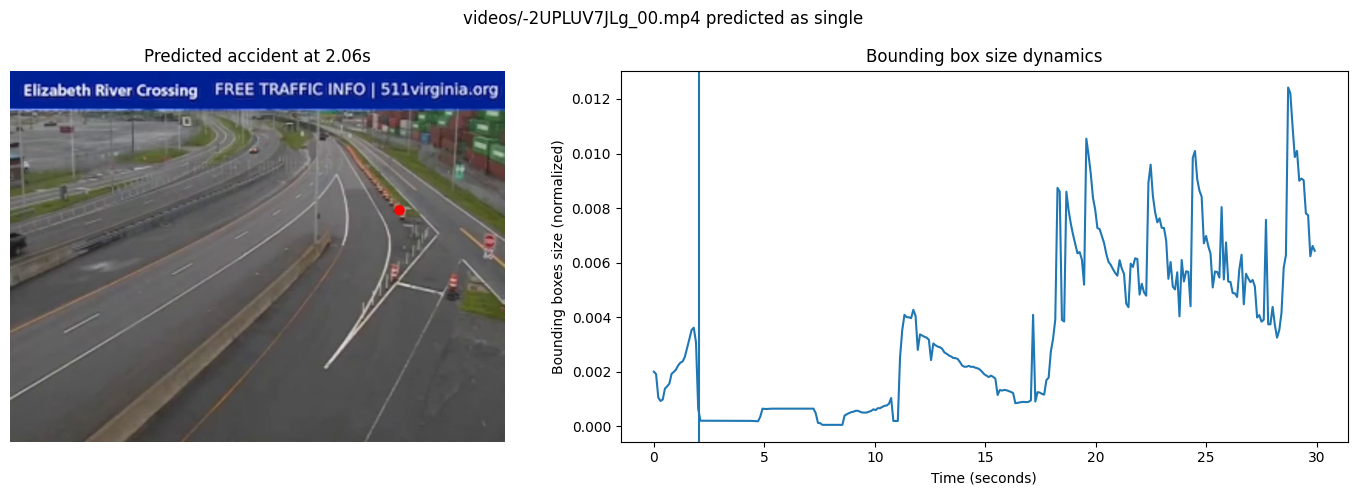

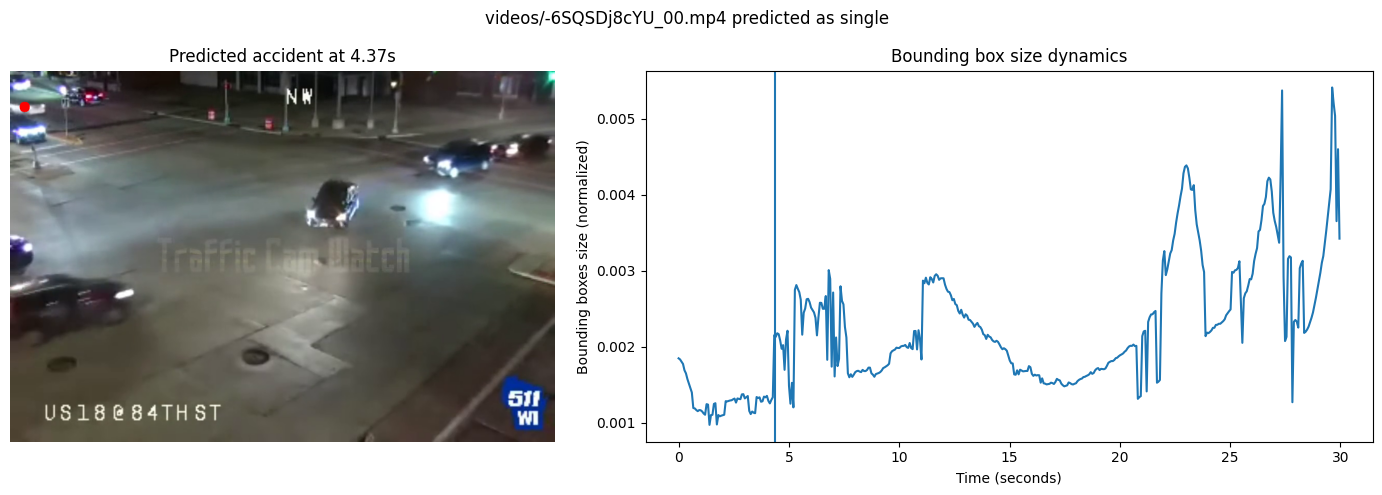

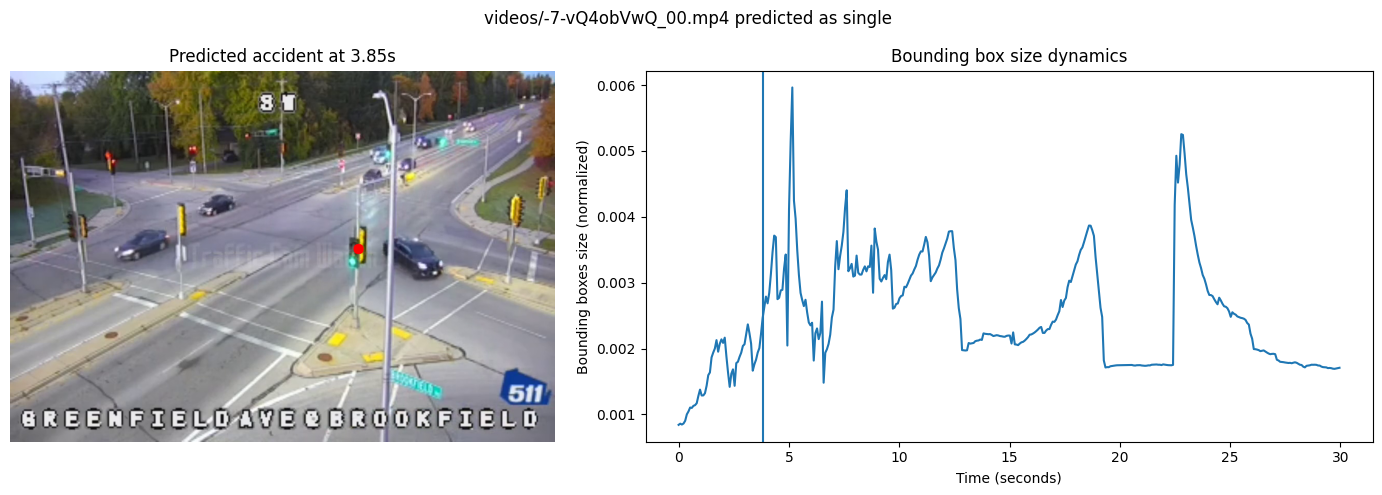

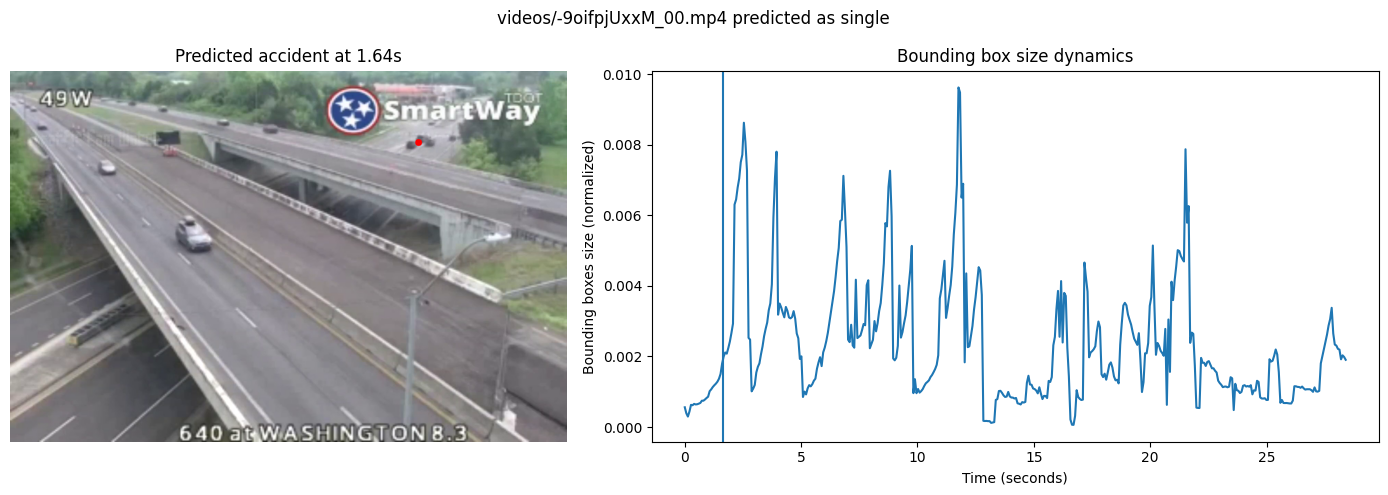

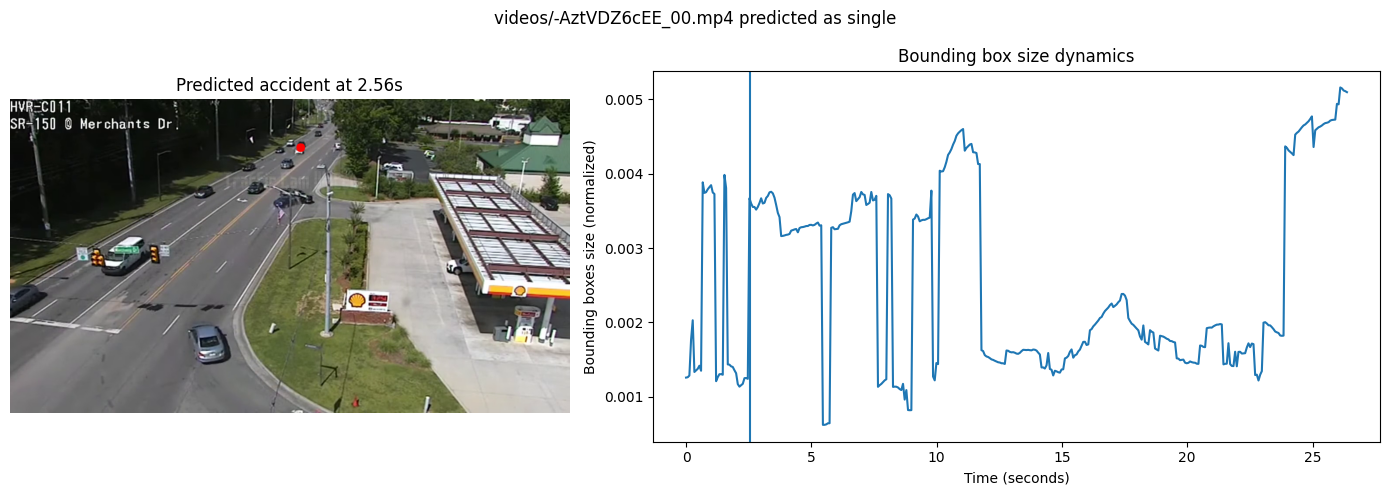

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_video_card(
    video_path,
    values_per_frame,
    fps,
    accident_time,
    center_x=None,
    center_y=None,
    title=None,
):
    # ---- Load accident frame ----
    cap = cv2.VideoCapture(video_path)
    frame_idx = int(accident_time * fps)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    ret, frame = cap.read()
    cap.release()

    if not ret:
        raise RuntimeError(f"Could not read frame from {video_path}")

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Optional: draw accident location
    if center_x is not None and center_y is not None:
        h, w, _ = frame.shape
        px = int(center_x * w)
        py = int(center_y * h)
        cv2.circle(frame, (px, py), 10, (255, 0, 0), -1)

    # ---- Prepare signal plot ----
    time = np.arange(len(values_per_frame)) / fps

    # ---- Build card ----
    fig, (ax_img, ax_plot) = plt.subplots(
        1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.3]}
    )

    # Image panel
    ax_img.imshow(frame)
    ax_img.set_title(f"Predicted accident at {accident_time:.2f}s")
    ax_img.axis("off")

    # Signal panel
    ax_plot.plot(time, values_per_frame)
    ax_plot.axvline(accident_time)
    ax_plot.set_xlabel("Time (seconds)")
    ax_plot.set_ylabel("Bounding boxes size (normalized)")
    ax_plot.set_title("Bounding box size dynamics")

    if title:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()

results: dict[Path, dict] = {}
for i, (_, row) in enumerate(results_df.iterrows()):
    if i >= (take or 5):
        break
    video = DATASET_PATH / row["path"]
    with open(DETECTIONS_PATH / video.with_suffix(".json").name, "r") as f:
        info = json.load(f)

    metadata = metadata_df.loc[info["path"]]
    fps = metadata["no_frames"] / metadata["duration"]
    
    frame, sizes = find_bbox_size_change(info)

    show_video_card(
        video_path=DATASET_PATH / row["path"],
        values_per_frame=sizes,
        fps=fps,
        accident_time=row["accident_time"],
        center_x=row["center_x"],
        center_y=row["center_y"],
        title=f"{row['path']} predicted as {row['type']}",
    )

## Results

In [10]:
from metrics import print_temporal_accuracy, print_spatial_accuracy

print_temporal_accuracy(results_df, DATASET_PATH)
print_spatial_accuracy(results_df, DATASET_PATH)


Temporal task:
____________________
| Sigma | Accuracy |
| 0.50  | 0.136    |
| 1.00  | 0.259    |
| 2.00  | 0.452    |


Spatial task:
Normalized sigmas:  0.1271988418398835 0.11881774725886773
____________________
| Sigma | Accuracy |
| 0.50  | 0.118    |
| 1.00  | 0.273    |
| 2.00  | 0.530    |




### Temporal info by ensemble

In [12]:
# Load ensemble results
results_ensemble = {}
for _, row in pd.read_csv("output_ensemble.csv").iterrows():
    fps = (
        metadata_df.loc[row["path"]]["no_frames"]
        / metadata_df.loc[row["path"]]["duration"]
    )
    results_ensemble[row["path"]] = {
        "frame": int(row["accident_time"] / fps),
        "accident_time": row["accident_time"],
    }

predict_accident_location(video_paths, results_ensemble)
print_spatial_accuracy(pd.DataFrame([{"path": str(path), **i, "frame": None } for path, i in results_ensemble.items()]).drop(columns=["frame"]), DATASET_PATH)

100%|██████████| 2027/2027 [00:31<00:00, 63.47it/s]

Spatial task:
Normalized sigmas:  0.1271988418398835 0.11881774725886773
____________________
| Sigma | Accuracy |
| 0.50  | 0.075    |
| 1.00  | 0.221    |
| 2.00  | 0.498    |




### Temporal info by oracle

In [ ]:
# Load true results
results_oracle = {}
for _, row in pd.read_csv(DATASET_PATH / "metadata-real.csv").iterrows():
    results_oracle[row["path"]] = {
        "frame": row["accident_frame"],
        "accident_time": row["accident_time"],
    }


predict_accident_location(video_paths, results_oracle)
print_spatial_accuracy(pd.DataFrame([{"path": str(path), **i, "frame": None } for path, i in results_oracle.items()]).drop(columns=["frame"]), DATASET_PATH)